In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_huggingface import ChatHuggingFace , HuggingFaceEndpoint
from typing import TypedDict, Annotated,Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator
import os

e:\AI_Learning\langgraph_learning\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
load_dotenv()

True

In [3]:
generator_llm = ChatHuggingFace(llm=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct", 
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"), 
))
evaluator_llm = ChatHuggingFace(llm=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct", 
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"), 
))
optimizer_llm = ChatHuggingFace(llm=HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-7B-Instruct", 
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"), 
))

In [4]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [5]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation,method="json_schema")

In [6]:
# state 
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iterations: int

    tweet_history: Annotated[list[str], operator.add] 
    feedback_history: Annotated[list[str], operator.add] 

In [7]:
def generate_tweet(state: TweetState) -> TweetState:
      # prompt
      messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    # send generator-llm
      response = generator_llm.invoke(messages).content

    # return response
      return { "tweet": response,'tweet_history': [response]}

In [8]:
def evaluate_tweet(state: TweetState) -> TweetState:
      # prompt
        messages = [
            SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
            HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
        response = structured_evaluator_llm.invoke(messages)

        return {
            "evaluation": response["evaluation"],
            "feedback": response["feedback"],
            "feedback_history": [response["feedback"]]
}

In [9]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [10]:
def route_evaluation(state: TweetState) -> str:
    if state['evaluation'] == "approved" or state['iteration'] >= state['max_iterations']:
        return "approved"
    else:
        return "needs_improvement"

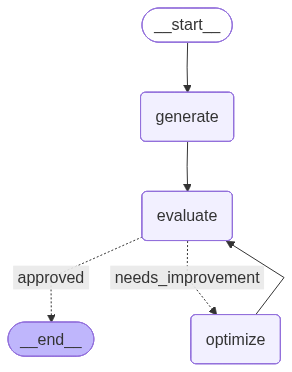

In [11]:
graph = StateGraph(TweetState)

# nodes
graph.add_node("generate",generate_tweet)
graph.add_node("evaluate",evaluate_tweet)
graph.add_node("optimize",optimize_tweet)

# edges
graph.add_edge(START, "generate")
graph.add_edge("generate", "evaluate")
graph.add_conditional_edges("evaluate",  route_evaluation, {'approved': END, 'needs_improvement': "optimize"})
graph.add_edge("optimize", "evaluate")

workflow = graph.compile()

workflow

In [12]:
initial_state = {
    "topic": "Egdbeq",
    "iteration": 1,
    "max_iterations": 5,}

result =workflow.invoke(initial_state)

In [13]:
result

{'topic': 'Egdbeq',
 'tweet': 'Egdbeq: The hero of midnight snacking and scapegoat of failed diets. 🍫😉 #EgdbeqWin #dietfail',
 'evaluation': 'approved',
 'feedback': 'The tweet is original in its play on words and the concept of midnight snacking. The humor is clever and relatable, as it addresses a common struggle many people face with late-night cravings. The tweet is punchy with its concise format and use of emojis, which adds a modern touch. It has strong virality potential as it taps into a universal theme in a unique way. The format is well-formed and stays within the character limit, making it scroll-stopping and shareable.',
 'iteration': 2,
 'max_iterations': 5,
 'tweet_history': ['Egdbeq—the secret ingredient in every failed diet and the star of every midnight snack binge. 🍫💪 #EgdbeqWin #dietfail',
  'Egdbeq: The hero of midnight snacking and scapegoat of failed diets. 🍫😉 #EgdbeqWin #dietfail'],
 'feedback_history': ["The tweet attempts to be humorous but falls short in sever

In [14]:
for tweet in result['tweet_history']:
    print("Generated Tweet:", tweet)

Generated Tweet: Egdbeq—the secret ingredient in every failed diet and the star of every midnight snack binge. 🍫💪 #EgdbeqWin #dietfail
Generated Tweet: Egdbeq: The hero of midnight snacking and scapegoat of failed diets. 🍫😉 #EgdbeqWin #dietfail
